# Aprendizaje no supervisado

Cuestionario 5 de la asignatura Aprendizaje Automático del Máster Universitario en
Lógica, Computación e Inteligencia Artificial.

Realizado por Manuel Enciso Martínez.

In [33]:
#Código copiado de la práctica

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import LogisticRegression

# Importar imágenes
from PIL import Image
import requests
from io import BytesIO

from sklearn.neural_network import MLPClassifier #MLP

# Nuevos
import random #para generar números aleatorios
import matplotlib.patches as patches #para dibujar formas geométricas

## Parte 1, clustering para diagnóstico médico

Vamos a buscar una imgen médica en internet de un TAC con piedras en el riñon.

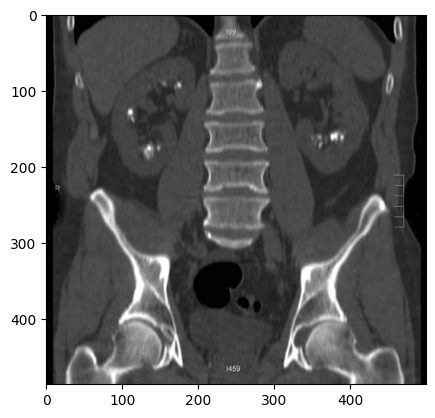

In [2]:
# URL raw de la imagen en GitHub
url = "https://www.radiologyinfo.org/-/media/radinfo/gallery-items/images/a-to-d/ct-kidney-stones.jpg?rev=3845f41b941545e1878c812d62c6a19b&hash=91349149FF57FFCAFED873BA470D4FF3"

# Descargamos la imagen
response = requests.get(url)
response.raise_for_status()  # verifica que todo esté OK

# La abrimos con Image de PIL
tac_riñones = Image.open(BytesIO(response.content))
# La pasamos a un array de numpy y normalizamos
tac_riñones_array = np.array(tac_riñones)/255
# Dibujamos la imagen
plt.imshow(tac_riñones_array);

Vamos a usar el paquete 'patches' para representar las zonas en las que se encuentran las piedras. 

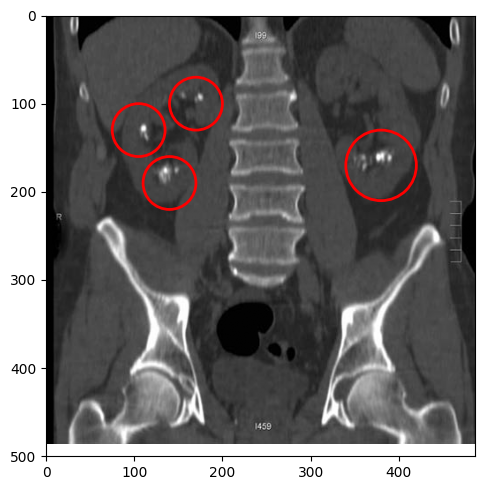

In [3]:
# Crear la figura y mostrar la imagen
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(tac_riñones_array)

# Definir los círculos con sus centros (x, y) y radios
circulos = [
    {'x': 170, 'y': 100, 'radio': 30},
    {'x': 105, 'y': 130, 'radio': 30},
    {'x': 140, 'y': 190, 'radio': 30},
    {'x': 380, 'y': 170, 'radio': 40}
]

# Dibujar los círculos
for circulo in circulos:
    circulo_obj = patches.Circle(
        (circulo['x'], circulo['y']),  # Centro (x, y)
        circulo['radio'],               # Radio
        linewidth=2,                    # Grosor del borde
        edgecolor='red',                # Color del borde
        facecolor='none'                # Sin relleno (solo el contorno)
    )
    ax.add_patch(circulo_obj)

# Opcional: ajustar los límites y aspecto
ax.set_xlim(0, 487)
ax.set_ylim(500, 0)  # Invertido para que el origen sea arriba-izquierda como en imágenes
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

A continuación vamos a realizar segmentación por colores mediante k-medias a la imagen original. Como estas zonas dentro de los circulos (para nuestro ejemplo, las piedras en el riñon) comparten misma tonalidad de color, van a ser clasificasdas en el mismo grupo.

Para hacer la segmentación de colores, primero vamos a representar la imagen como una lista de píxeles, representando cada píxel con su correspondiente tonalidad (ya que un TAC esta en blanco y negro).

In [4]:
X_tac_riñones = tac_riñones_array.reshape(-1, 1)
print(X_tac_riñones.shape)
X_tac_riñones[:10]

(730500, 1)


array([[0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157],
       [0.00392157]])

Ahora vamos a reducir las tonalidades en 4,3 y 2 grupos. Observamos que en cada uno de los casos las piedras pertenecen a la misma clasificación.

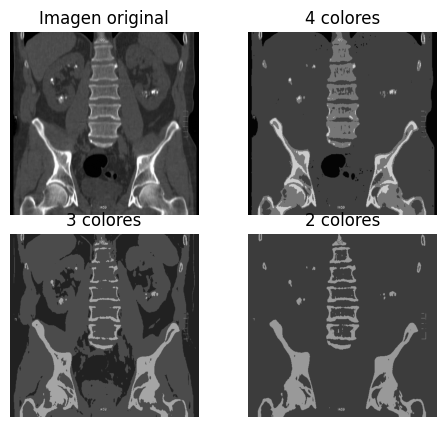

In [5]:
segmented_imgs = []
n_colors = (4, 3, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, random_state=2026).fit(X_tac_riñones)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(tac_riñones_array.shape))

plt.figure(figsize=(6,5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(221)
plt.imshow(tac_riñones_array)
plt.title("Imagen original")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(222 + idx)
    plt.imshow(segmented_imgs[idx])
    plt.title("{} colores".format(n_clusters))
    plt.axis('off')

plt.show()

En ocasiones, puede resultar dificil distinguir las distintas tonalidades de grises. Para intentar mejorar esto, podemos añadir un mapa de color de manera que las distintas clasificaciones se representen por colores más llamativos y distinguibles.

Observación, hemos elegido un mapa de color que me resulta personalmente distingibles. Pero en la práctica, habría que tener en cuenta la elección de colores para la gente con algún tipo de daltonismo (como confundir el rojo con el verde).

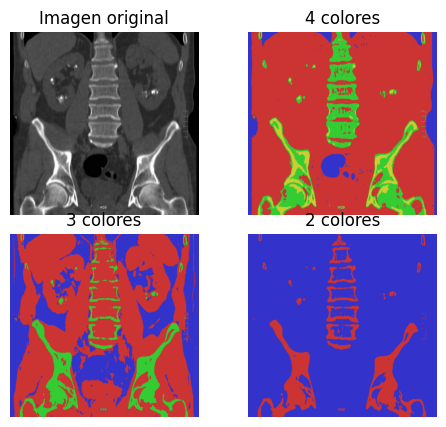

In [6]:
segmented_imgs_rgb = []

CUSTOM_COLORS = {
    0: np.array([0.2, 0.2, 0.8]),      # Azul oscuro
    1: np.array([0.8, 0.2, 0.2]),      # Rojo oscuro
    2: np.array([0.2, 0.8, 0.2]),      # Verde oscuro
    3: np.array([0.8, 0.8, 0.2]),      # Amarillo oscuro
}

for img_idx, segmented_img in enumerate(segmented_imgs):
    
    height, width, channels = segmented_img.shape
    

    pixels = segmented_img.reshape(-1, 3)
    
    # Encontrar todos los colores únicos (son iguales al número de clusters)
    unique_colors = np.unique(pixels, axis=0)
    n_unique = len(unique_colors)

    # Crear mapa de color: color_original -> color_nuevo
    color_mapping = {}
    for color_idx, original_color in enumerate(unique_colors):
        # Convertir el color a una tupla para usarlo como clave del diccionario
        color_tuple = tuple(original_color)
        color_mapping[color_tuple] = CUSTOM_COLORS[color_idx % len(CUSTOM_COLORS)]
    
    # Crear imagen RGB asignando colores según el mapeo
    img_rgb = np.zeros((height, width, 3), dtype=np.float32)
    
    for h in range(height):
        for w in range(width):
            original_color = tuple(segmented_img[h, w, :]) #Color original del pixel altura h, ancho w
            img_rgb[h, w, :] = color_mapping[original_color] #Asignar el color nuevo según el mapeo
    
    segmented_imgs_rgb.append(img_rgb)

plt.figure(figsize=(6,5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(221)
plt.imshow(tac_riñones_array)
plt.title("Imagen original")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(222 + idx)
    plt.imshow(segmented_imgs_rgb[idx])
    plt.title("{} colores".format(n_clusters))
    plt.axis('off')

plt.show()

Para el caso más simple de dos colores, se observa una clara delimitación de las piedras en comparación con la imagen original.

Estas técnicas de segmentación pueden resultar útiles como herramienta complementaria para ayudar al médico, permitiéndole priorizar aquellas zonas donde se detectan tonalidades similares, reduciendo así el riesgo de diagnósticos incompletos. Sin embargo, el criterio del experto sigue siendo fundamental para distinguir observaciones relevantes. Por ejemplo, para nuestro TAC, las manchas detectadas en los laterales superiores de las piedras (y clasificadas en el mismo cluster de las piedras) corresponden simplemente a las costillas.

También destacar que resulta útil ir reduciendo la clasificación de manera escalonada. Permitiendo descartar progresivamente las observaciones normales a medida que se unifica la información, reduciendo así la complejidad del análisis final.

---

## Parte 2, MLP y K-medias

Hemos elegido el dataset de clasificación de vinos

In [7]:
from sklearn.datasets import load_wine
data = load_wine()

Veamos que contienen el dataset.

In [8]:
print(data.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

Separamos los datos entre conjunto de entrenamiento y prueba.

In [9]:
X_data = data.data
Y_data = data.target

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data, stratify=Y_data,
                                                    random_state=2026,test_size=0.1)

Elementos en el conjunto de pruebas

In [10]:
np.shape(X_test)

(18, 13)

Nuestro conjunto de prueba consta de 18 datos.

In [17]:
random.seed(2026) #Fijar semilla para reproducibilidad de la libreria random

Pruebas = 100 #Número de pruebas a realizar

mejor_configuracion = None
mejor_rendimiento_prueba = 0

for iteracion in range(Pruebas):
    length = random.randint(1, 10) #números de capas de la red
    lista = [random.randint(2, 30) for _ in range(length)] #número de neuronas por capa
    mlp = MLPClassifier(solver="lbfgs",max_iter=5000,random_state=2026,hidden_layer_sizes=lista)
    mlp.fit(X_train, Y_train)
    if mlp.score(X_test, Y_test) > mejor_rendimiento_prueba:
        mejor_rendimiento_prueba = mlp.score(X_test, Y_test)
        mejor_configuracion = lista


print("\n")
print("Mejor configuración encontrada: {}".format(mejor_configuracion))
print("Mejor rendimiento en el conjunto de prueba: {:.2f}".format(mejor_rendimiento_prueba))

c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s)



Mejor configuración encontrada: [22, 17, 15, 13, 27, 26, 30, 26, 30, 19]
Mejor rendimiento en el conjunto de prueba: 1.00


c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Tenemos que con 17 categorías debemos predecir a qué grupo de vino que pertenece cada instancia. Hemos logrado encontrar un perceptrón multicapa con un rendimiento del 100% de aciertos en el conjunto de prueba.

In [18]:
mlp = MLPClassifier(solver="lbfgs",max_iter=5000,random_state=2026,hidden_layer_sizes=mejor_configuracion)
mlp.fit(X_train, Y_train)

print("Rendimiento del MLP en el conjunto de datos completo: {:.2f}".format(mlp.score(X_data, Y_data)))
print("Rendimiento del MLP en el conjunto de entrenamiento: {:.2f}".format(mlp.score(X_train, Y_train)))
print("Rendimiento del MLP en el conjunto de prueba: {:.2f}".format(mlp.score(X_test, Y_test)))

Rendimiento del MLP en el conjunto de datos completo: 0.96
Rendimiento del MLP en el conjunto de entrenamiento: 0.95
Rendimiento del MLP en el conjunto de prueba: 1.00


Vamos a aplicar K-medias para reducir la dimensionalidad y observar como afecta esto al rendimiento de la clasificación.

In [19]:
# Reducir las 17 categorías originales a 8 clusters
kmeans = KMeans(n_clusters=8, random_state=2026)
kmeans.fit(X_train)


,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,2026
,copy_x,True
,algorithm,'lloyd'


In [20]:
# Calcular los centroides
centroids = kmeans.cluster_centers_

# Transformar datos de entrenamiento a espacio de distancias
distance_space_train = pairwise_distances(X_train, centroids)

# Transformar datos de prueba a espacio de distancias
distance_space_test = pairwise_distances(X_test, centroids)

# Entrenar el MLP en el espacio de distancias 
mlp = MLPClassifier(solver="lbfgs", max_iter=5000, random_state=2026, hidden_layer_sizes=mejor_configuracion)
mlp.fit(distance_space_train, Y_train)

# Evaluar en el conjunto de prueba
score = mlp.score(distance_space_test, Y_test)
print(f"Rendimiento del MLP con reducción de dimensionalidad: {score:.2f}")

Rendimiento del MLP con reducción de dimensionalidad: 0.83


Hemos perdido rendimiento a costa de reducir dimensionalidad a más de la mitad. 

Aunque esto se debe en parte a que la arquitectura que estamos implementando era la que mejor rendimiento daba en el caso original, podemos tratar de realizar una busqueda de nuevas arquitecturas de capas y neuronas para comprobar si encontramos alguna con mejor rendimiento sobre el conjunto de pruebas.

In [21]:
random.seed(2026) #Fijar semilla para reproducibilidad de la libreria random

Pruebas = 100 #Número de pruebas a realizar

mejor_configuracion = None
mejor_rendimiento_prueba = 0

for iteracion in range(Pruebas):
    length = random.randint(1, 10) #números de capas de la red
    lista = [random.randint(2, 30) for _ in range(length)] #número de neuronas por capa
    mlp = MLPClassifier(solver="lbfgs",max_iter=5000,random_state=2026,hidden_layer_sizes=lista)
    mlp.fit(distance_space_train, Y_train)
    if mlp.score(distance_space_test, Y_test) > mejor_rendimiento_prueba:
        mejor_rendimiento_prueba = mlp.score(distance_space_test, Y_test)
        mejor_configuracion = lista


print("\n")
print("Mejor configuración encontrada: {}".format(mejor_configuracion))
print("Mejor rendimiento en el conjunto de prueba: {:.2f}".format(mejor_rendimiento_prueba))

c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s)



Mejor configuración encontrada: [23, 12, 8, 14, 10, 13, 13, 27]
Mejor rendimiento en el conjunto de prueba: 0.89


c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Resulta que la nueva arquitectura de [23, 12, 8, 14, 10, 13, 13, 27] obtiene una mejora del rendimiento sobre el conjunto de pruebas al 89%.

También podemos tratar de variar la reducción de la dimensionalidad, probando distintos número de clusters para clasificar, comparando rendimientos sobre el conjunto de pruebas.

In [ ]:
random.seed(2026) #Fijar semilla para reproducibilidad de la libreria random
Pruebas = 100 #Número de pruebas a realizar

rendimiento_lista = []
configuracion_lista = []


for n_clusters in range(2, 14): #Probar con diferentes números de clusters
    mejor_rendimiento = 0
    mejor_arquitectura = None

    kmeans = KMeans(n_clusters=n_clusters, random_state=2026)
    kmeans.fit(X_train)

    centroids = kmeans.cluster_centers_

    distance_space_train = pairwise_distances(X_train, centroids)

    distance_space_test = pairwise_distances(X_test, centroids)

    for iteracion in range(Pruebas):
        length = random.randint(1, 10) #números de capas de la red
        lista = [random.randint(2, 30) for _ in range(length)] #número de neuronas por capa
        mlp = MLPClassifier(solver="lbfgs",max_iter=5000,random_state=2026,hidden_layer_sizes=lista)
        mlp.fit(distance_space_train, Y_train)
        if mlp.score(distance_space_test, Y_test) > mejor_rendimiento:
            mejor_rendimiento = mlp.score(distance_space_test, Y_test)
            mejor_arquitectura = lista

    rendimiento_lista.append(mejor_rendimiento)
    configuracion_lista.append(mejor_arquitectura)

for i in range(2, 14):
    print("\n")
    print("Para número de clusters = " + str(i))
    print("Mejor configuración encontrada: {}".format(configuracion_lista[i-2]))
    print("Mejor rendimiento en el conjunto de prueba: {:.2f}".format(rendimiento_lista[i-2]))

c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s)



Para número de clusters = 2
Mejor configuración encontrada: [13, 13, 16, 22]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 3
Mejor configuración encontrada: [6, 5, 12, 17]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 4
Mejor configuración encontrada: [20, 29, 18]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 5
Mejor configuración encontrada: [24, 15, 3, 22, 22, 12, 29, 13]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 6
Mejor configuración encontrada: [22, 13, 4, 15]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 7
Mejor configuración encontrada: [10, 25, 14, 26, 5, 18]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 8
Mejor configuración encontrada: [21, 17, 4, 14, 20, 23, 17]
Mejor rendimiento en el conjunto de prueba: 0.89


Para número de clusters = 9
Mejor configuración encontrada: [17, 19, 10, 20,

c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Observamos que para cualquier número de clusters, el máximo rendimiento que podemos llegar a tener es 89%. Lo cual resulta especialmente sorprendente para el caso de redimensionar a 2, como vemos a continuación.

In [28]:
# Realizamos clustering
kmeans_prep = KMeans(n_clusters=2, random_state=2026)
kmeans_prep.fit(X_train)

# Obtenemos los centroides
centroids_prep = kmeans_prep.cluster_centers_

# Calculamos la distancias de los puntos de X_train a los centroides.
distance_space_train = pairwise_distances(X_train, centroids_prep)

# Hacemos lo mismo con el conjunto de test
distance_space_test = pairwise_distances(X_test, centroids_prep)

mlp = MLPClassifier(solver="lbfgs",max_iter=5000,random_state=2026,hidden_layer_sizes=configuracion_lista[0])
mlp.fit(distance_space_train, Y_train)

print("Mejor configuración encontrada: {}".format(configuracion_lista[0]))
print("Mejor redimensionalización (número de clusters): {}".format(2))
print("Mejor rendimiento en el conjunto de prueba: {:.2f}".format(mlp.score(distance_space_test, Y_test)))

Mejor configuración encontrada: [13, 13, 16, 22]
Mejor redimensionalización (número de clusters): 2
Mejor rendimiento en el conjunto de prueba: 0.89


Aunque no hemos conseguido superar el 89% de aciertos, se puede ver como un logro igualarlo reduciendo drásticamente la dimensionalidad a 2.

Veamos la reducción de la que tratamos.

In [29]:


print("Dimension original de los datos:")
print("Dimensión de X_train:", np.shape(X_train))
print("Primeros 5 vectores en X_train:\n", X_train[:5])

print("\n")
print("Dimensión reducida de los datos:")
print("Dimensión de distance_space_train:", np.shape(distance_space_train))
print("Primeros 5 vectores en distance_space_train:\n", distance_space_train[:5])

Dimension original de los datos:
Dimensión de X_train: (160, 13)
Primeros 5 vectores en X_train:
 [[1.181e+01 2.120e+00 2.740e+00 2.150e+01 1.340e+02 1.600e+00 9.900e-01
  1.400e-01 1.560e+00 2.500e+00 9.500e-01 2.260e+00 6.250e+02]
 [1.351e+01 1.800e+00 2.650e+00 1.900e+01 1.100e+02 2.350e+00 2.530e+00
  2.900e-01 1.540e+00 4.200e+00 1.100e+00 2.870e+00 1.095e+03]
 [1.288e+01 2.990e+00 2.400e+00 2.000e+01 1.040e+02 1.300e+00 1.220e+00
  2.400e-01 8.300e-01 5.400e+00 7.400e-01 1.420e+00 5.300e+02]
 [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.430e+01 1.920e+00 2.720e+00 2.000e+01 1.200e+02 2.800e+00 3.140e+00
  3.300e-01 1.970e+00 6.200e+00 1.070e+00 2.650e+00 1.280e+03]]


Dimensión reducida de los datos:
Dimensión de distance_space_train: (160, 2)
Primeros 5 vectores en distance_space_train:
 [[532.40713666  67.04689263]
 [ 61.80139875 525.90984255]
 [626.68549855  39.93881033]
 [ 93.94374867

Para terminar, podemos analizar mediante 'learning_curve' de sklearn el rendimiento del clasificador para distintos tamaños de conjuntos de pruebas.

Para ello usamos la misma configuración y datos de entrenamiento para la clasificación para k=2. Vamos


c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 3 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\encis\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 2 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\encis\AppData\Local\Temp\ipykernel_1896\1917622224.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignor

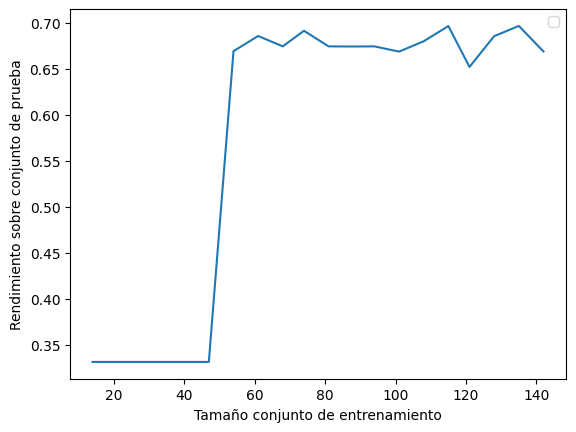

In [39]:
kmeans = KMeans(n_clusters=2, random_state=2026)
kmeans.fit(X_data)

centroids = kmeans.cluster_centers_

distance_space = pairwise_distances(X_data, centroids)

train_sizes, _, test_scores = learning_curve(
    MLPClassifier(hidden_layer_sizes=configuracion_lista[0], solver='lbfgs', max_iter=5000),
    distance_space, Y_data,
    train_sizes=np.linspace(0.1, 1, 20)
)

plt.plot(train_sizes, test_scores.mean(axis=1))
plt.xlabel('Tamaño conjunto de entrenamiento')
plt.ylabel('Rendimiento sobre conjunto de prueba')
plt.legend()
plt.show()


Observamos un gran cambio favorable cuando aumentamos el conjunto de entrenamiento de 40 a 60, y esta mejoría parece mantenerse estable ya para estos valores más altos. 

Por lo que sugire que, para nuestro ejemplo, podríamos haber obtenido valores de rendimientos similares usando conjuntos de pruebas mayores. Lo que equivale a haber usado un menor número de instancias de entrenamiento y obtener rendimiento similar.

---

## Parte 3, aprendizaje semisupervisado

Para esta parte, hemos utilizado el dataset: Ilter, N. & Guvenir, H. (1998). Dermatology [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5FK5P.

In [18]:
# Importamos el dataset
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
dermatology = fetch_ucirepo(id=33) 
  
# data (as pandas dataframes) 
X_data2 = dermatology.data.features 
Y_data2 = dermatology.data.targets 
  
# metadata 
print(dermatology.metadata) 
  
# variable information 
print(dermatology.variables) 


{'uci_id': 33, 'name': 'Dermatology', 'repository_url': 'https://archive.ics.uci.edu/dataset/33/dermatology', 'data_url': 'https://archive.ics.uci.edu/static/public/33/data.csv', 'abstract': 'Aim for this dataset is to determine the type of Eryhemato-Squamous Disease.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 366, 'num_features': 34, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Feb 14 2024', 'dataset_doi': '10.24432/C5FK5P', 'creators': ['Nilsel Ilter', 'H. Guvenir'], 'intro_paper': {'ID': 387, 'type': 'NATIVE', 'title': 'Learning differential diagnosis of erythemato-squamous diseases using voting feature intervals', 'authors': 'H. Altay Güvenir, G. Demiröz, N. Ilter', 'venue': 'Artif. Intell. Medicine', 'year': 1998, 'journal': No

In [19]:
# Mostrar las primeras 5 filas del DataFrame
X_data2.head()

,erythema,scaling,definite-borders,itching,koebner phenomenon,polygonal papules,follicular papules,oral-mucosal involvement,knee elbow involvement,scalp involvement,...,focal hypergranulosis,disappearance of the granular layer,vacuolisation and damage of the basal layer,spongiosis,saw-tooth appearance of retes,follicular horn plug,perifollicular parakeratosis,inflammatory monoluclear infiltrate,band-like infiltrate,age
0,2,2,0,3,0,0,0,0,1,0,...,0,0,0,3,0,0,0,1,0,55.0
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,8.0
2,2,1,2,3,1,3,0,3,0,0,...,2,0,2,3,2,0,0,2,3,26.0
3,2,2,2,0,0,0,0,0,3,2,...,0,3,0,0,0,0,0,3,0,40.0
4,2,3,2,2,2,2,0,2,0,0,...,2,2,3,2,3,0,0,2,3,45.0


Obtengamos la dimensión del conjunto de datos.

In [20]:
np.shape(X_data2)

(366, 34)

Tenemos 366 instancias y 34 categorías para clasificar 6 posibles categorías objetivo.

Resulta que algunas instancias no tienen ningun valor en la categoría de edad.

In [21]:
instancias_vacias = sum(1 for i in X_data2['age'] if pd.isna(i))

print("El ",instancias_vacias / np.shape(X_data2)[0] * 100,"% de las instancias tienen valores vacíos en la columna 'age'")

El  2.185792349726776 % de las instancias tienen valores vacíos en la columna 'age'


Podríamos tratar de rellenarlas con un valor medio del resto de instancias, o mediante aproximación por vecinos más proximos. Pero como son tan pocas, vamos a decidir simplemente eliminarlas del estudio.

In [22]:
# Encontrar índices donde Age NO es NaN
indices_validos = X_data2['age'].notna()

# Filtrar ambos dataframes
X_data2_clean = X_data2[indices_validos]
Y_data2_clean = Y_data2[indices_validos]

In [23]:
instancias_vacias = sum(1 for i in X_data2_clean['age'] if pd.isna(i))

print("El ",instancias_vacias / np.shape(X_data2_clean)[0] * 100,"% de las instancias tienen valores vacíos en la columna 'age'")

El  0.0 % de las instancias tienen valores vacíos en la columna 'age'


Vamos a separar en conjunto de prueba y entrenamiento y usar regresión lineal como clasificador.

In [24]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X_data2_clean, Y_data2_clean, stratify=Y_data2_clean,
                                                    random_state=2026, test_size=0.1)

# Convertir targets a 1D para compatibilidad con sklearn
Y_train2 = Y_train2.values.ravel()
Y_test2 = Y_test2.values.ravel()



In [25]:
n_labeled = 36 

log_reg = LogisticRegression(solver="lbfgs", random_state=2026, max_iter=5000)
log_reg.fit(X_train2[:n_labeled], Y_train2[:n_labeled]) 
score = log_reg.score(X_test2, Y_test2)
print(f"Rendimiento de LogisticRegression: {score:.2f}")

Rendimiento de LogisticRegression: 0.92


Obtenemos un 92% de rendimiento 

Vamos a utilizar K-meadias, con k = 36, para obtener las instancias más representativas.

In [26]:
k = 36
kmeans = KMeans(n_clusters=k, random_state=2026)

X_derma = kmeans.fit_transform(X_train2)  # Distancia de cada muestra a cada centro
derma_idx = np.argmin(X_derma, axis=0)    # Para cada centro, la posición de la muestra más cercana (representativa)
X_representative_derma = X_train2.iloc[derma_idx]  # X_train2 mas representativas (iloc para mantener el DataFrame)
y_representative_derma = Y_train2[derma_idx]  # Y_train2 mas representativas

# Representamos las caracteristicas de las 5 instancias mas representativas.
print("Muestras representativas (primeras 5 filas):")
print(X_representative_derma.head())

Muestras representativas (primeras 5 filas):
     erythema  scaling  definite-borders  itching  koebner phenomenon  \
291         2        2                 2        0                   1   
276         3        2                 2        2                   0   
211         2        3                 2        0                   0   
339         2        1                 2        2                   2   
16          2        2                 1        3                   0   

     polygonal papules  follicular papules  oral-mucosal involvement  \
291                  0                   0                         0   
276                  0                   0                         0   
211                  0                   0                         0   
339                  3                   0                         2   
16                   0                   0                         0   

     knee elbow involvement  scalp involvement  ...  focal hypergranulosis  \
291  

c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [27]:
np.shape(X_representative_derma)

(36, 34)

Vamos a ver como mejora el usar estas instancias representativas en el entrenamiento del clasificador.

In [28]:
log_reg = LogisticRegression(solver="lbfgs", max_iter=5000,random_state=2026)
log_reg.fit(X_representative_derma, y_representative_derma)
log_reg.score(X_test2, Y_test2)

0.9444444444444444

Hemos aumentado hasta el 94.44% el rendimiento sobre el conjunto de prueba, al usar las instancias más representativas.

Veamos las clasificaciones de las instancias más representativas.

In [29]:
y_representative_derma

array([1, 1, 1, 3, 2, 1, 5, 4, 6, 5, 1, 1, 3, 2, 3, 4, 2, 3, 1, 1, 1, 4,
       1, 4, 3, 1, 4, 1, 3, 3, 2, 2, 1, 5, 3, 1], dtype=int64)

Veamos ahora qué pasa si usamos todos los datos, pero *propagando* el valor de clasificación desde las instancias más representativas representativas, a las que están en el mismo clúster:

In [30]:
y_train2_propagated = np.empty(len(X_train2), dtype=np.int32)

for i in range(k):   # en cada cluster asignamos la clase de la imagen representativa
    y_train2_propagated[kmeans.labels_==i] = y_representative_derma[i]

log_reg = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=2026)
log_reg.fit(X_train2, y_train2_propagated)
log_reg.score(X_test2, Y_test2)

0.6666666666666666

Hemos empeorado el rendimiento. Observamos que la distribución de clasificación para las instancias del conjunto representativo y el de entrenamiento es similar.

In [31]:
total_representative = len(X_representative_derma)
total = len(Y_train2)

for y in range(1, 7):
    sum_y_train2 = sum(Y_train2 == y)
    sum_y_representative = sum(y_representative_derma == y)
    print("=========================================")
    print(f"Clase {y}: {sum_y_train2/total} instancias en Y_train2")
    print(f"Clase {y}: {sum_y_representative/total_representative} instancias en el conjunto representativo")

Clase 1: 0.3105590062111801 instancias en Y_train2
Clase 1: 0.3888888888888889 instancias en el conjunto representativo
Clase 2: 0.16770186335403728 instancias en Y_train2
Clase 2: 0.1388888888888889 instancias en el conjunto representativo
Clase 3: 0.19875776397515527 instancias en Y_train2
Clase 3: 0.2222222222222222 instancias en el conjunto representativo
Clase 4: 0.13354037267080746 instancias en Y_train2
Clase 4: 0.1388888888888889 instancias en el conjunto representativo
Clase 5: 0.13354037267080746 instancias en Y_train2
Clase 5: 0.08333333333333333 instancias en el conjunto representativo
Clase 6: 0.055900621118012424 instancias en Y_train2
Clase 6: 0.027777777777777776 instancias en el conjunto representativo


Aun así hemos podido ser muy restrictivos al clasificar todas las instancias en el mismo cluster con la clasificación de la instancia más representativa, vamos a varíar el porcentaje de esta nueva clasificación para distintos percentiles para comprobar cual proporciona mejores resultados.

In [32]:
percentile_closest_list = [0,10,20,30,40,50,60,70,80,90,100]

for percentile_closest in percentile_closest_list:
    print("=========================================")
    print(f"Percentil considerado: {percentile_closest}")
    X_cluster_dist = X_derma[np.arange(len(X_train2)), kmeans.labels_] # distancia al centro más cercano
    for i in range(k):     # Para cada clúster
        in_cluster = (kmeans.labels_ == i)
        cluster_dist = X_cluster_dist[in_cluster] # distancias dentro de ese grupo
        cutoff_distance = np.percentile(cluster_dist, percentile_closest) # percentil
        above_cutoff = (X_cluster_dist > cutoff_distance) # las que quedan fuera del percentil las ponemos a -1
        X_cluster_dist[in_cluster & above_cutoff] = -1

    partially_propagated = (X_cluster_dist != -1)
    X_train2_partially_propagated = X_train2[partially_propagated]
    y_train_partially_propagated = y_train2_propagated[partially_propagated]

    log_reg = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=2026)
    log_reg.fit(X_train2_partially_propagated, y_train_partially_propagated)
    print(f"Accuracy con percentil {percentile_closest}: {log_reg.score(X_test2, Y_test2)}")

Percentil considerado: 0
Accuracy con percentil 0: 0.9444444444444444
Percentil considerado: 10
Accuracy con percentil 10: 0.9166666666666666
Percentil considerado: 20
Accuracy con percentil 20: 0.8611111111111112
Percentil considerado: 30
Accuracy con percentil 30: 0.8611111111111112
Percentil considerado: 40
Accuracy con percentil 40: 0.8333333333333334
Percentil considerado: 50
Accuracy con percentil 50: 0.7777777777777778
Percentil considerado: 60
Accuracy con percentil 60: 0.7222222222222222
Percentil considerado: 70
Accuracy con percentil 70: 0.8055555555555556
Percentil considerado: 80
Accuracy con percentil 80: 0.7777777777777778
Percentil considerado: 90
Accuracy con percentil 90: 0.75
Percentil considerado: 100
Accuracy con percentil 100: 0.6666666666666666


Observamos que el mejor rendimiento se obtiene cuando no realizamos la propagación del conjunto de instancias más representativas. Esto puede deberse principalmente a la selección del parámetro K, posiblemente estemos diviendo a las instancias de entrenamiento en clusters que no agrupan realmente a elementos de la misma clase y por eso la propagación de la clase empeore el rendimiento.


 Veamos que esto no siempre es así, si variamos el parámetro K de clusters obtenemos resultados diferentes.

In [35]:

percentile_closest_list = [0,10,20,30,40,50,60,70,80,90,100]
k_list = [12,14,16,18,20,22,24,26,28,30,32,34,36]

for k in k_list:
    print("=========================================")
    print(f"Número de clusters: {k}")
    print("\n")
    kmeans = KMeans(n_clusters=k, random_state=2026)

    X_derma = kmeans.fit_transform(X_train2)  # Distancia de cada muestra a cada centro
    derma_idx = np.argmin(X_derma, axis=0)    # Para cada centro, la posición de la muestra más cercana (representativa)
    X_representative_derma = X_train2.iloc[derma_idx]  # X_train2 mas representativas (iloc para mantener el DataFrame)
    y_representative_derma = Y_train2[derma_idx]  # Y_train2 mas representativas

    for percentile_closest in percentile_closest_list:
        X_cluster_dist = X_derma[np.arange(len(X_train2)), kmeans.labels_] # distancia al centro más cercano
        for i in range(k):     # Para cada clúster
            in_cluster = (kmeans.labels_ == i)
            cluster_dist = X_cluster_dist[in_cluster] # distancias dentro de ese grupo
            cutoff_distance = np.percentile(cluster_dist, percentile_closest) # percentil
            above_cutoff = (X_cluster_dist > cutoff_distance) # las que quedan fuera del percentil las ponemos a -1
            X_cluster_dist[in_cluster & above_cutoff] = -1

        partially_propagated = (X_cluster_dist != -1)
        X_train2_partially_propagated = X_train2[partially_propagated]
        y_train_partially_propagated = y_train2_propagated[partially_propagated]

        log_reg = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=2026)
        log_reg.fit(X_train2_partially_propagated, y_train_partially_propagated)
        print(f"Accuracy con percentil {percentile_closest}: {log_reg.score(X_test2, Y_test2)}")

Número de clusters: 12


Accuracy con percentil 0: 0.75
Accuracy con percentil 10: 0.8611111111111112
Accuracy con percentil 20: 0.8888888888888888


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.75
Accuracy con percentil 40: 0.75
Accuracy con percentil 50: 0.6388888888888888
Accuracy con percentil 60: 0.6666666666666666
Accuracy con percentil 70: 0.6666666666666666
Accuracy con percentil 80: 0.6944444444444444
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 14


Accuracy con percentil 0: 0.75
Accuracy con percentil 10: 0.9444444444444444
Accuracy con percentil 20: 0.8611111111111112


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.8055555555555556
Accuracy con percentil 40: 0.6944444444444444
Accuracy con percentil 50: 0.7777777777777778
Accuracy con percentil 60: 0.75
Accuracy con percentil 70: 0.6944444444444444
Accuracy con percentil 80: 0.6944444444444444
Accuracy con percentil 90: 0.7222222222222222
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 16


Accuracy con percentil 0: 0.6944444444444444
Accuracy con percentil 10: 0.6666666666666666


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 20: 0.7777777777777778
Accuracy con percentil 30: 0.6944444444444444
Accuracy con percentil 40: 0.6944444444444444
Accuracy con percentil 50: 0.7222222222222222
Accuracy con percentil 60: 0.6944444444444444
Accuracy con percentil 70: 0.6944444444444444
Accuracy con percentil 80: 0.6944444444444444
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 18


Accuracy con percentil 0: 0.7222222222222222
Accuracy con percentil 10: 0.6388888888888888
Accuracy con percentil 20: 0.6944444444444444


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.6111111111111112
Accuracy con percentil 40: 0.7222222222222222
Accuracy con percentil 50: 0.6944444444444444
Accuracy con percentil 60: 0.7222222222222222
Accuracy con percentil 70: 0.6666666666666666
Accuracy con percentil 80: 0.75
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 20


Accuracy con percentil 0: 0.6388888888888888
Accuracy con percentil 10: 0.6666666666666666


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 20: 0.6944444444444444
Accuracy con percentil 30: 0.5833333333333334
Accuracy con percentil 40: 0.6944444444444444
Accuracy con percentil 50: 0.7222222222222222
Accuracy con percentil 60: 0.7222222222222222
Accuracy con percentil 70: 0.7222222222222222
Accuracy con percentil 80: 0.7777777777777778
Accuracy con percentil 90: 0.6944444444444444
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 22


Accuracy con percentil 0: 0.9166666666666666
Accuracy con percentil 10: 0.8611111111111112
Accuracy con percentil 20: 0.8055555555555556


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.7222222222222222
Accuracy con percentil 40: 0.6944444444444444
Accuracy con percentil 50: 0.6666666666666666
Accuracy con percentil 60: 0.7777777777777778
Accuracy con percentil 70: 0.8055555555555556
Accuracy con percentil 80: 0.7777777777777778
Accuracy con percentil 90: 0.75
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 24


Accuracy con percentil 0: 0.9444444444444444
Accuracy con percentil 10: 0.7777777777777778
Accuracy con percentil 20: 0.8333333333333334


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.6944444444444444
Accuracy con percentil 40: 0.6944444444444444
Accuracy con percentil 50: 0.75
Accuracy con percentil 60: 0.6944444444444444
Accuracy con percentil 70: 0.7777777777777778
Accuracy con percentil 80: 0.7777777777777778
Accuracy con percentil 90: 0.6944444444444444
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 26


Accuracy con percentil 0: 0.9166666666666666
Accuracy con percentil 10: 0.8611111111111112
Accuracy con percentil 20: 0.8333333333333334


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.6944444444444444
Accuracy con percentil 40: 0.6666666666666666
Accuracy con percentil 50: 0.7777777777777778
Accuracy con percentil 60: 0.6944444444444444
Accuracy con percentil 70: 0.7777777777777778
Accuracy con percentil 80: 0.8055555555555556
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 28


Accuracy con percentil 0: 0.9166666666666666
Accuracy con percentil 10: 0.8333333333333334
Accuracy con percentil 20: 0.8333333333333334


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.75
Accuracy con percentil 40: 0.75
Accuracy con percentil 50: 0.7777777777777778
Accuracy con percentil 60: 0.7777777777777778
Accuracy con percentil 70: 0.7777777777777778
Accuracy con percentil 80: 0.75
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 30


Accuracy con percentil 0: 0.9166666666666666
Accuracy con percentil 10: 0.8333333333333334
Accuracy con percentil 20: 0.8333333333333334


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.7222222222222222
Accuracy con percentil 40: 0.7777777777777778
Accuracy con percentil 50: 0.8055555555555556
Accuracy con percentil 60: 0.75
Accuracy con percentil 70: 0.7777777777777778
Accuracy con percentil 80: 0.75
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 32


Accuracy con percentil 0: 0.9444444444444444
Accuracy con percentil 10: 0.8888888888888888
Accuracy con percentil 20: 0.8888888888888888


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.8611111111111112
Accuracy con percentil 40: 0.8333333333333334
Accuracy con percentil 50: 0.8055555555555556
Accuracy con percentil 60: 0.8055555555555556
Accuracy con percentil 70: 0.8333333333333334
Accuracy con percentil 80: 0.7777777777777778
Accuracy con percentil 90: 0.6666666666666666
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 34


Accuracy con percentil 0: 0.9444444444444444
Accuracy con percentil 10: 0.9166666666666666
Accuracy con percentil 20: 0.8611111111111112


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.8611111111111112
Accuracy con percentil 40: 0.8333333333333334
Accuracy con percentil 50: 0.7777777777777778
Accuracy con percentil 60: 0.7222222222222222
Accuracy con percentil 70: 0.8055555555555556
Accuracy con percentil 80: 0.7777777777777778
Accuracy con percentil 90: 0.75
Accuracy con percentil 100: 0.6666666666666666
Número de clusters: 36


Accuracy con percentil 0: 0.9444444444444444
Accuracy con percentil 10: 0.9166666666666666
Accuracy con percentil 20: 0.8611111111111112


c:\Users\encis\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Accuracy con percentil 30: 0.8611111111111112
Accuracy con percentil 40: 0.8333333333333334
Accuracy con percentil 50: 0.7777777777777778
Accuracy con percentil 60: 0.7222222222222222
Accuracy con percentil 70: 0.8055555555555556
Accuracy con percentil 80: 0.7777777777777778
Accuracy con percentil 90: 0.75
Accuracy con percentil 100: 0.6666666666666666


El aprendizaje semisupervisado es una técnica útil en escenarios donde: 
* La clasificación es costosa y requiere tiempo, por ejemplo cuando se necesita la ayuda de expertos para la clasificación. Para ello podemos implementar algún algoritmos para dividir el conjunto en clusters y clasificar las instancias más próximas a los centroides y propagar el valor de las clases a las instancias del mismo clusters, ahorrando tiempo/coste en clasificar el resto de instancias.
* La clasificiación de las instancias se ha realizado mediante la validación de varios expertos y alguno de ellos cuenta con mayor tasa de acierto, por ejemplo si se observa que el rendimiento de clasificación de un experto es mayor debido a la larga trayectoria laboral que ha tenido. Entonces podríamos utilizarlo como una técnica de validación, antes de entrenar algun modelo con las etiquetas originales, comprobar que estas clasificaciones coinciden en cierta medida con alguna propagación de clases más representativas del experto con mayor experiencia.